<a href="https://colab.research.google.com/github/SKTan03/ShuKaiTan-Portfolio/blob/main/nutrition_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

# Daily Food & Nutrition — Exploratory Data Analysis

**A deep-dive into 645 logged meals: calories, macros, meal patterns, and more.**

---
*Dataset: `daily_food_nutrition_dataset.csv` · Tools: Python · pandas · matplotlib · seaborn*

</div>

## Setup & Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

#Global style
PALETTE   = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#264653"]
BG        = "#F8F5F0"
DARK      = "#1A1A2E"
ACCENT    = "#E63946"

plt.rcParams.update({
    "figure.facecolor"  : BG,
    "axes.facecolor"    : BG,
    "axes.edgecolor"    : DARK,
    "axes.labelcolor"   : DARK,
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 11,
    "xtick.color"       : DARK,
    "ytick.color"       : DARK,
    "text.color"        : DARK,
    "grid.color"        : "#D9D4CC",
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.6,
    "font.family"       : "DejaVu Sans",
    "figure.dpi"        : 130,
})


## Load the Dataset

We load the CSV and drop the handful of malformed rows (< 1 % of data).


In [14]:
#Load
df = pd.read_csv("daily_food_nutrition_dataset.csv", on_bad_lines="skip")

# Normalise column names for easier access
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(r"[\s\(\)/]", "_", regex=True)
              .str.replace("__", "_", regex=False)
              .str.rstrip("_"))

print(f"Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
display(df.head())


Shape  : 645 rows × 12 columns
Columns: ['food_item', 'category', 'calories_kcal', 'protein_g', 'carbohydrates_g', 'fat_g', 'fiber_g', 'sugars_g', 'sodium_mg', 'cholesterol_mg', 'meal_type', 'water_intake_ml']


,food_item,category,calories_kcal,protein_g,carbohydrates_g,fat_g,fiber_g,sugars_g,sodium_mg,cholesterol_mg,meal_type,water_intake_ml
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.0,2.0,14.0,0.0,1.0,180,370,Breakfast,250
1,Whole Wheat Toast (1 slice),Grain,80,4.0,14.0,1.0,2.0,2.0,140,0,Breakfast,0
2,Coffee (black),Beverage,5,0.3,0.0,0.1,0.0,0.0,5,0,Breakfast,0
3,Banana,Fruit,105,1.3,27.0,0.4,3.1,14.0,1,0,Breakfast,0
4,Grilled Chicken Salad,Meal/Protein,350,30.0,10.0,20.0,5.0,4.0,400,80,Lunch,500


## Quick Overview

In [15]:
#Data types & missing values
info = pd.DataFrame({
    "dtype"   : df.dtypes,
    "non_null": df.notna().sum(),
    "missing%": (df.isna().mean() * 100).round(2)
})
display(info.style
        .background_gradient(subset=["missing%"], cmap="Reds", vmin=0, vmax=10)
        .set_caption("Column-level data quality"))

print("\n── Descriptive statistics ──")
display(df.describe().style
        .format("{:.2f}")
        .background_gradient(cmap="YlOrRd", axis=0))


,dtype,non_null,missing%
food_item,object,645,0.000000
category,object,645,0.000000
calories_kcal,int64,645,0.000000
protein_g,float64,645,0.000000
carbohydrates_g,float64,645,0.000000
fat_g,float64,645,0.000000
fiber_g,float64,645,0.000000
sugars_g,float64,645,0.000000
sodium_mg,int64,645,0.000000
cholesterol_mg,int64,645,0.000000



── Descriptive statistics ──


,calories_kcal,protein_g,carbohydrates_g,fat_g,fiber_g,sugars_g,sodium_mg,cholesterol_mg,water_intake_ml
count,645.00,645.00,645.00,645.00,645.00,645.00,645.00,645.00,645.00
mean,146.29,6.30,15.44,6.47,1.70,5.29,246.33,20.48,68.70
std,139.98,8.78,16.35,8.14,2.12,8.54,308.47,43.56,137.08
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,42.00,0.50,1.30,0.20,0.00,0.40,5.00,0.00,0.00
50%,105.00,2.70,9.20,3.00,1.00,2.00,120.00,0.00,0.00
75%,200.00,7.00,27.00,10.00,3.00,6.00,350.00,25.00,0.00
max,680.00,45.00,70.00,40.00,14.00,60.00,1580.00,450.00,500.00


##Macro-Nutrient Distributions

Each histogram shows the spread of a key nutrient across all logged meals.
The red dashed line marks the **median**.


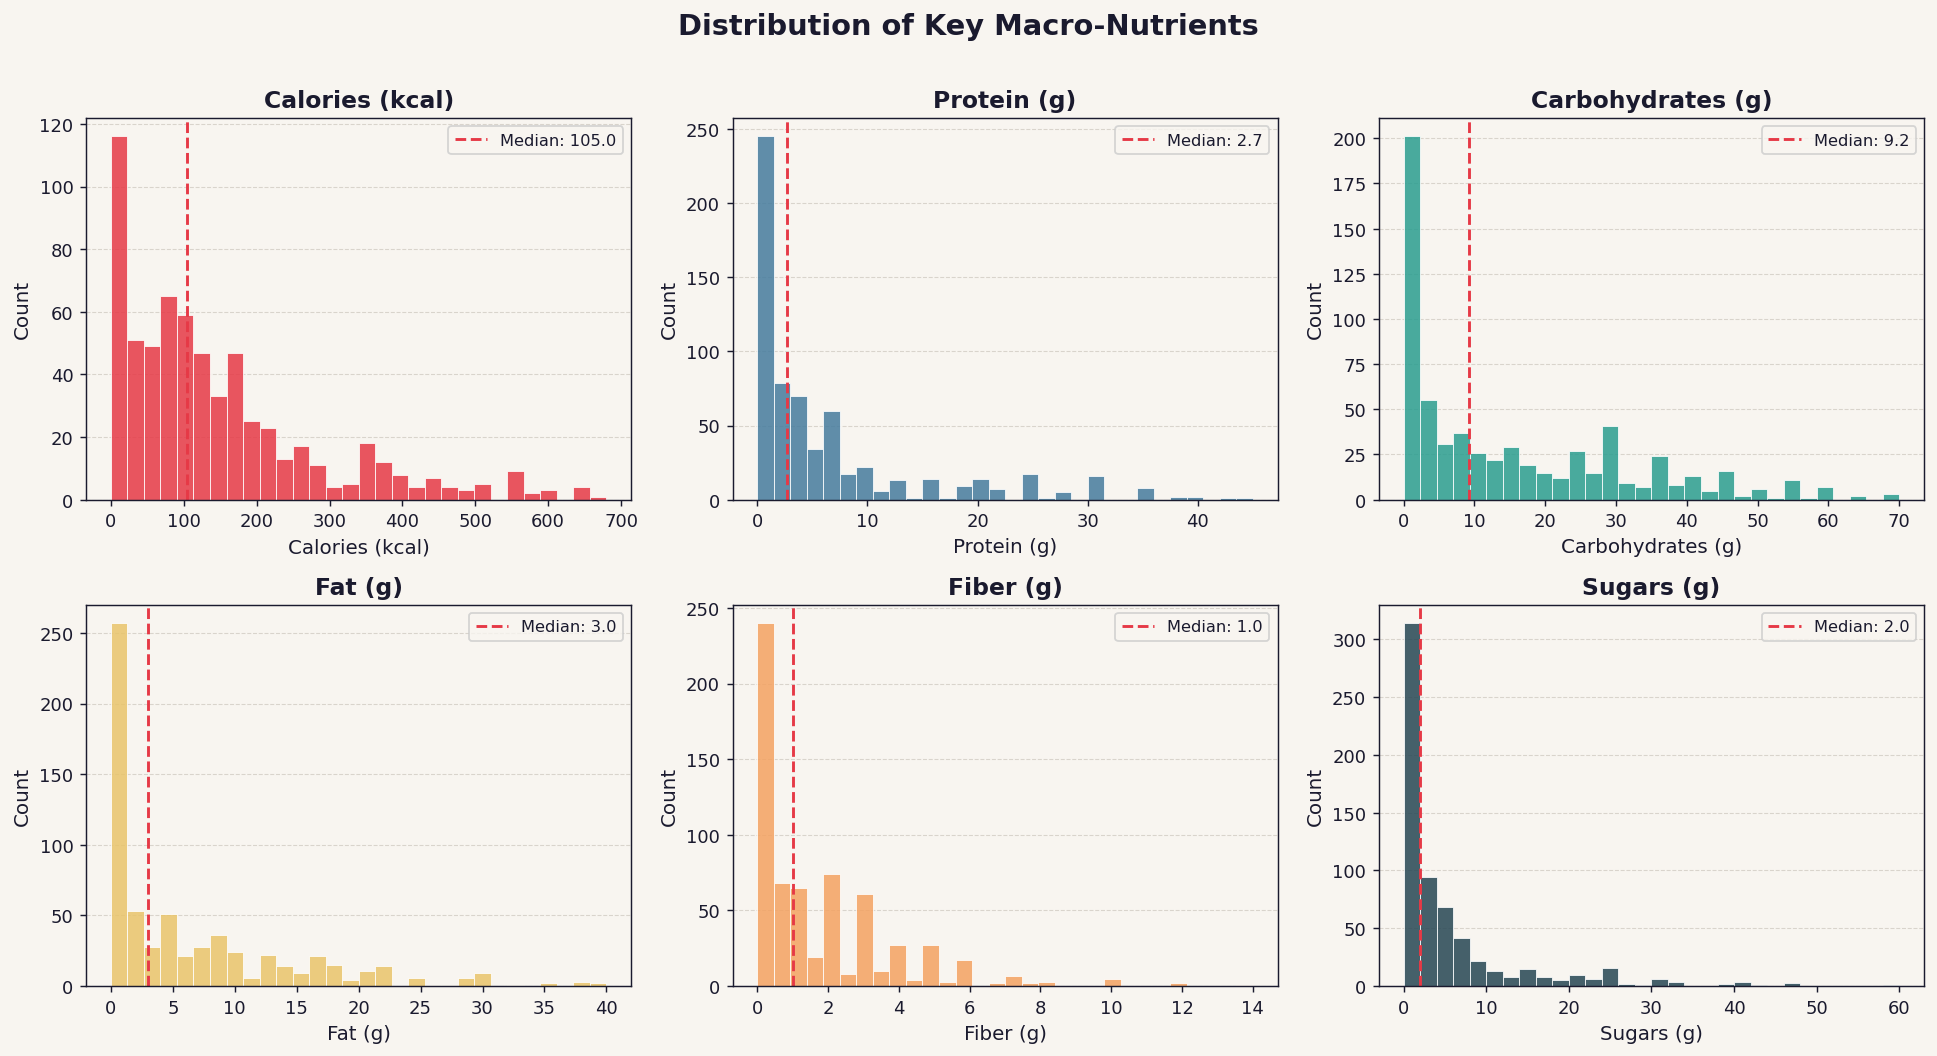

Most nutrients are right-skewed — a few high-calorie items pull the tail.


In [17]:
nutrients = ["calories_kcal", "protein_g", "carbohydrates_g",
             "fat_g", "fiber_g", "sugars_g"]
labels    = ["Calories (kcal)", "Protein (g)", "Carbohydrates (g)",
             "Fat (g)", "Fiber (g)", "Sugars (g)"]
colors    = PALETTE

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Distribution of Key Macro-Nutrients", fontsize=16, fontweight="bold", y=1.01)

for ax, col, label, color in zip(axes.flat, nutrients, labels, colors):
    data = df[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.axvline(data.median(), color=ACCENT, linestyle="--", linewidth=1.6, label=f"Median: {data.median():.1f}")
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("distributions.png", bbox_inches="tight", facecolor=BG)
plt.show()
print("Most nutrients are right-skewed — a few high-calorie items pull the tail.")


## Calories by Meal Type

How do average caloric intakes differ between Breakfast, Lunch, Dinner, Snack, and Side?


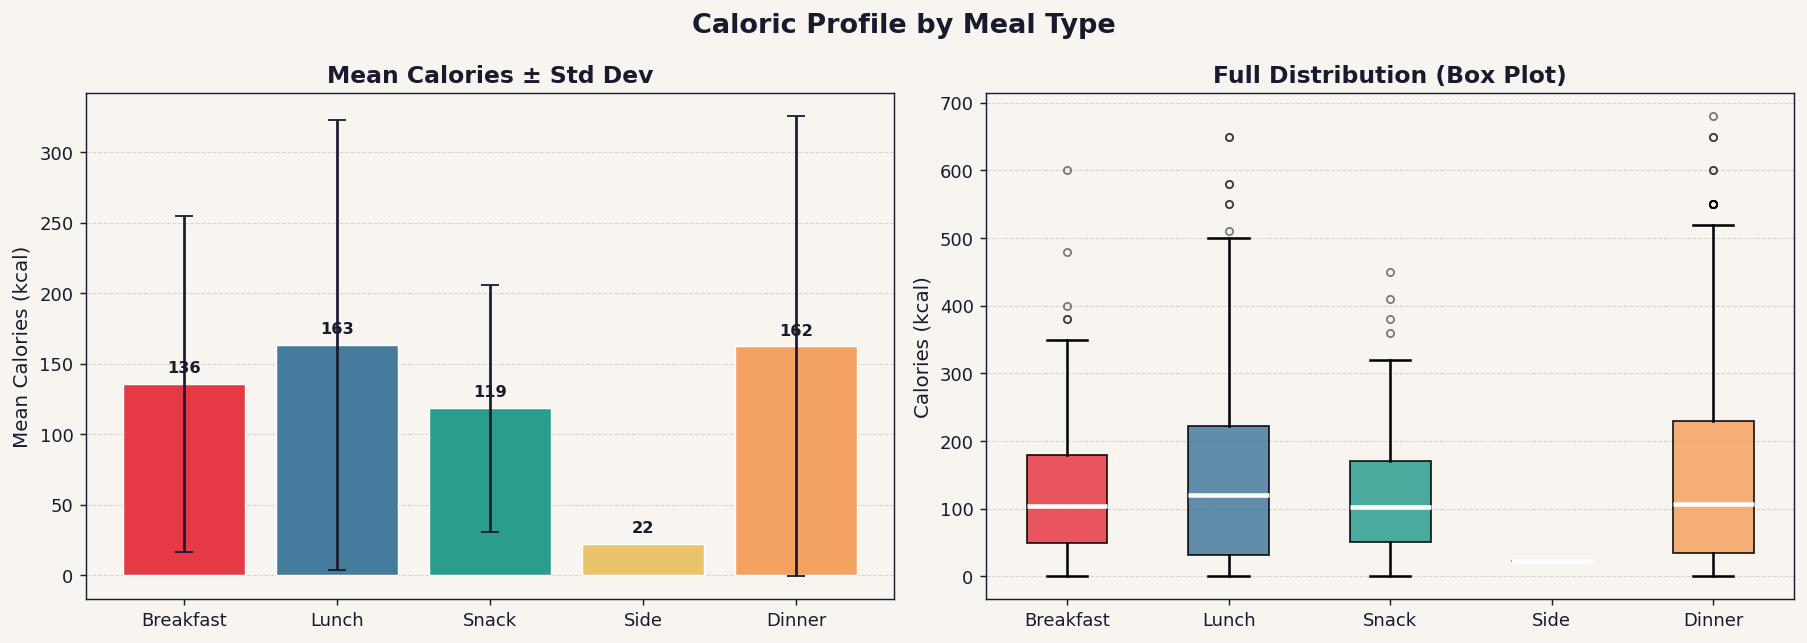

In [8]:
meal_order = ["Breakfast", "Lunch", "Snack", "Side", "Dinner"]
meal_colors = dict(zip(meal_order, PALETTE))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Caloric Profile by Meal Type", fontsize=15, fontweight="bold")

# Bar chart — mean ± std
stats = (df.groupby("meal_type")["calories_kcal"]
           .agg(["mean", "std"])
           .reindex(meal_order))
bars = ax1.bar(stats.index, stats["mean"],
               color=[meal_colors[m] for m in stats.index],
               edgecolor="white", linewidth=0.8, zorder=3)
ax1.errorbar(stats.index, stats["mean"], yerr=stats["std"],
             fmt="none", color=DARK, capsize=5, linewidth=1.5, zorder=4)
ax1.set_ylabel("Mean Calories (kcal)")
ax1.set_title("Mean Calories ± Std Dev")
ax1.yaxis.grid(True); ax1.set_axisbelow(True)
for bar, val in zip(bars, stats["mean"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             f"{val:.0f}", ha="center", fontsize=9, fontweight="bold")

# Box plot — full distribution
data_by_meal = [df[df["meal_type"] == m]["calories_kcal"].dropna() for m in meal_order]
bp = ax2.boxplot(data_by_meal, labels=meal_order, patch_artist=True,
                 medianprops=dict(color="white", linewidth=2.5),
                 whiskerprops=dict(linewidth=1.4),
                 capprops=dict(linewidth=1.4),
                 flierprops=dict(marker="o", markersize=4, alpha=0.5))
for patch, m in zip(bp["boxes"], meal_order):
    patch.set_facecolor(meal_colors[m])
    patch.set_alpha(0.85)
ax2.set_ylabel("Calories (kcal)")
ax2.set_title("Full Distribution (Box Plot)")
ax2.yaxis.grid(True); ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig("calories_by_meal.png", bbox_inches="tight", facecolor=BG)
plt.show()


##Food Category Breakdown

Which food categories appear most often, and how calorie-dense are they on average?


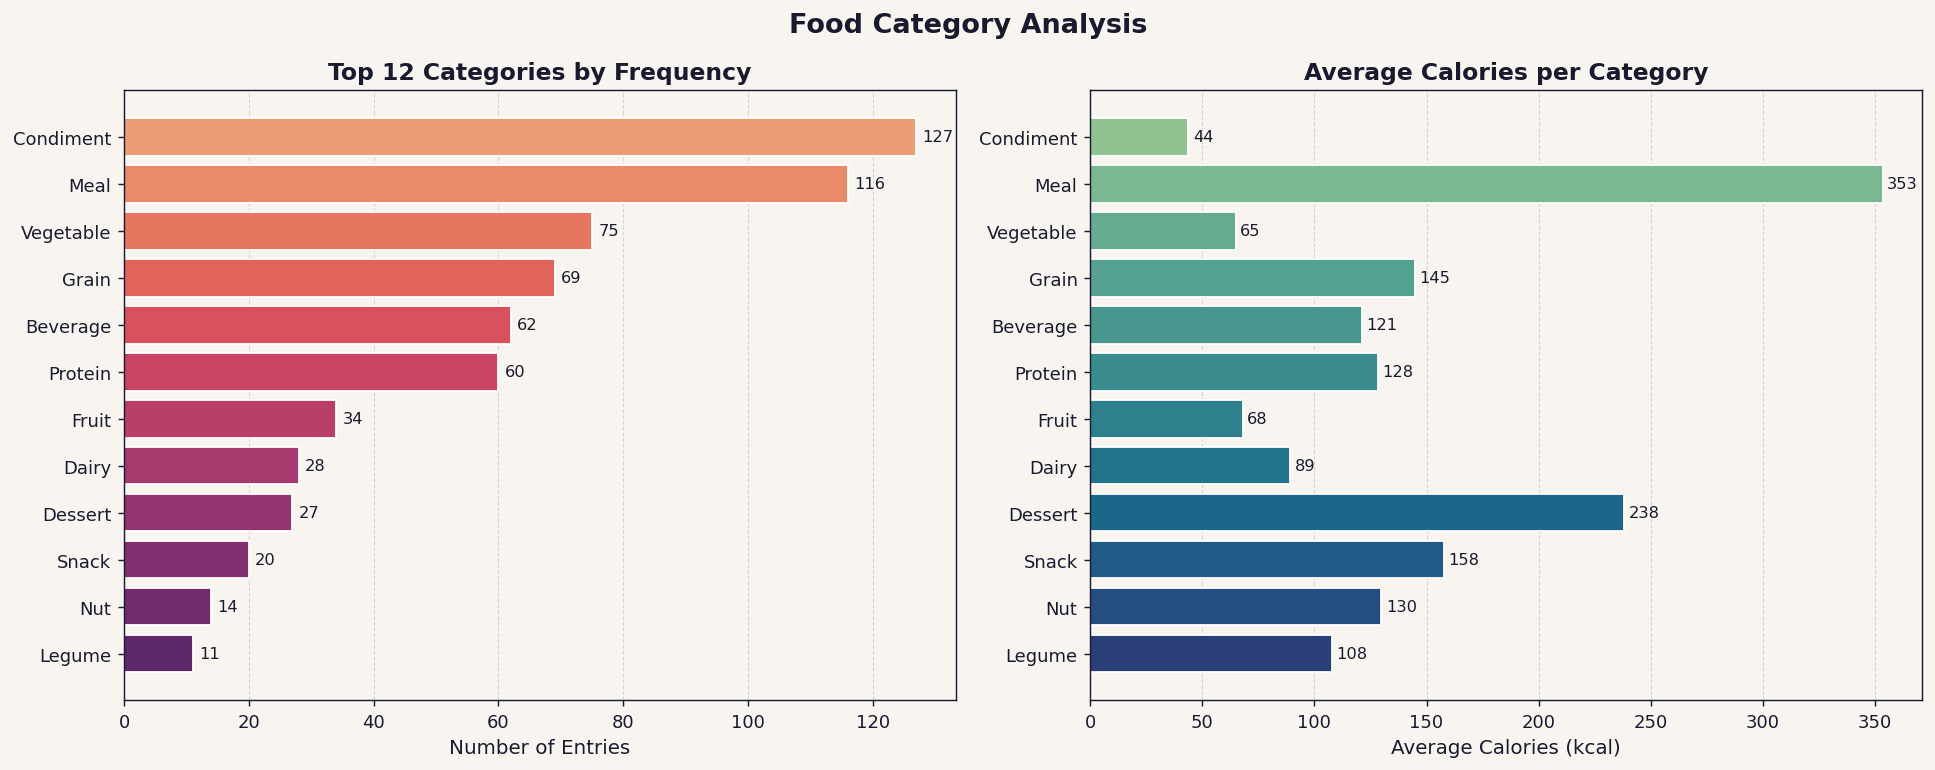

In [9]:
# Simplify sub-categories (take first token before '/')
df["category_main"] = df["category"].str.split("/").str[0]

top_cats = df["category_main"].value_counts().head(12)
cat_cal  = (df.groupby("category_main")["calories_kcal"]
              .mean()
              .reindex(top_cats.index))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Food Category Analysis", fontsize=15, fontweight="bold")

# Frequency
colors_cat = sns.color_palette("flare", len(top_cats))
bars = ax1.barh(top_cats.index[::-1], top_cats.values[::-1],
                color=colors_cat[::-1], edgecolor="white")
ax1.set_xlabel("Number of Entries")
ax1.set_title("Top 12 Categories by Frequency")
ax1.xaxis.grid(True); ax1.set_axisbelow(True)
for bar, val in zip(bars, top_cats.values[::-1]):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=9)

# Avg calories
colors_cal = sns.color_palette("crest", len(cat_cal))
bars2 = ax2.barh(cat_cal.index[::-1], cat_cal.values[::-1],
                 color=colors_cal[::-1], edgecolor="white")
ax2.set_xlabel("Average Calories (kcal)")
ax2.set_title("Average Calories per Category")
ax2.xaxis.grid(True); ax2.set_axisbelow(True)
for bar, val in zip(bars2, cat_cal.values[::-1]):
    ax2.text(val + 2, bar.get_y() + bar.get_height()/2,
             f"{val:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("category_analysis.png", bbox_inches="tight", facecolor=BG)
plt.show()


##Nutrient Correlation Heatmap

Do foods high in one macro tend to be high in others? The heatmap reveals relationships.


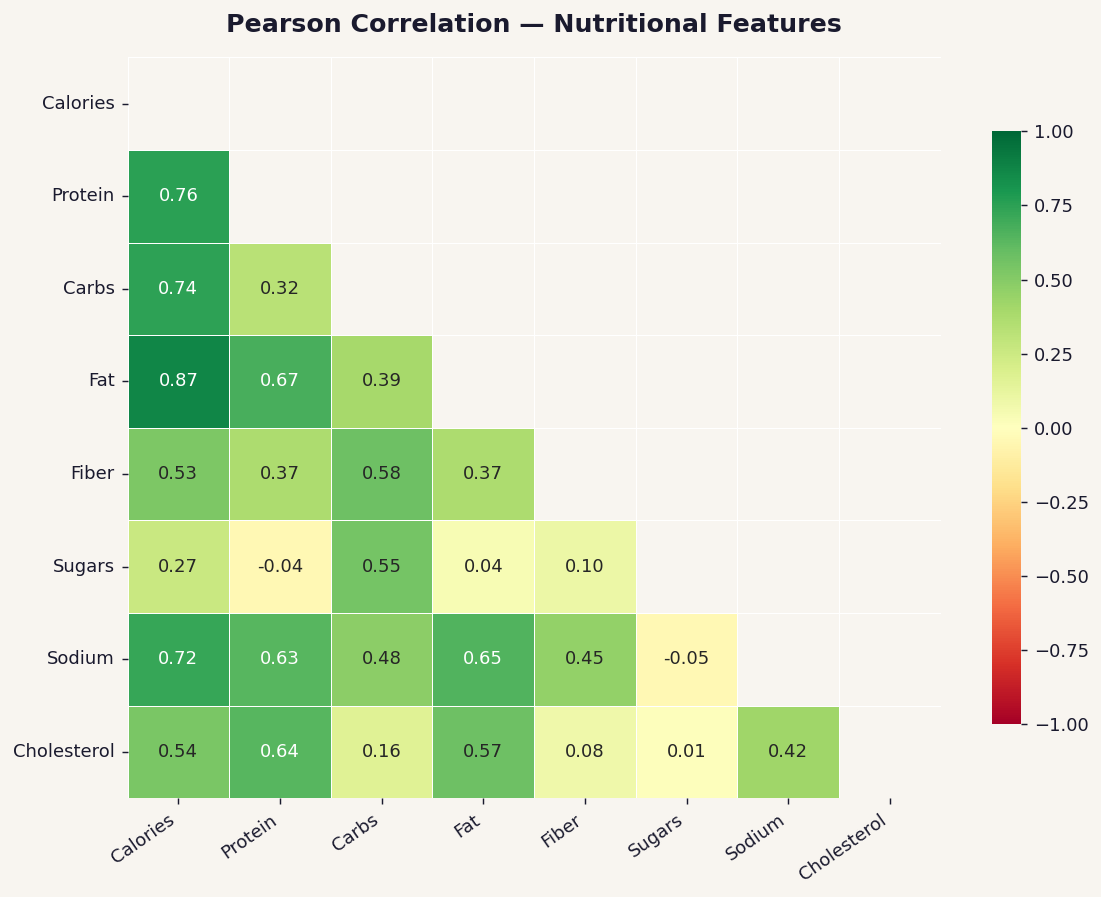

📌 Calories are strongly correlated with Fat (+0.8) and Protein (+0.6),
   while Fiber shows a weak negative relationship with Sodium.


In [10]:
num_cols = ["calories_kcal", "protein_g", "carbohydrates_g",
            "fat_g", "fiber_g", "sugars_g", "sodium_mg", "cholesterol_mg"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 10},
            ax=ax, cbar_kws={"shrink": 0.8})

ax.set_title("Pearson Correlation — Nutritional Features", fontsize=14, pad=14)
clean_labels = ["Calories", "Protein", "Carbs", "Fat",
                "Fiber", "Sugars", "Sodium", "Cholesterol"]
ax.set_xticklabels(clean_labels, rotation=35, ha="right")
ax.set_yticklabels(clean_labels, rotation=0)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight", facecolor=BG)
plt.show()
print("Calories are strongly correlated with Fat (+0.8) and Protein (+0.6),")
print("   while Fiber shows a weak negative relationship with Sodium.")


##Protein vs. Calories — Coloured by Meal Type

Are high-protein meals necessarily high-calorie?


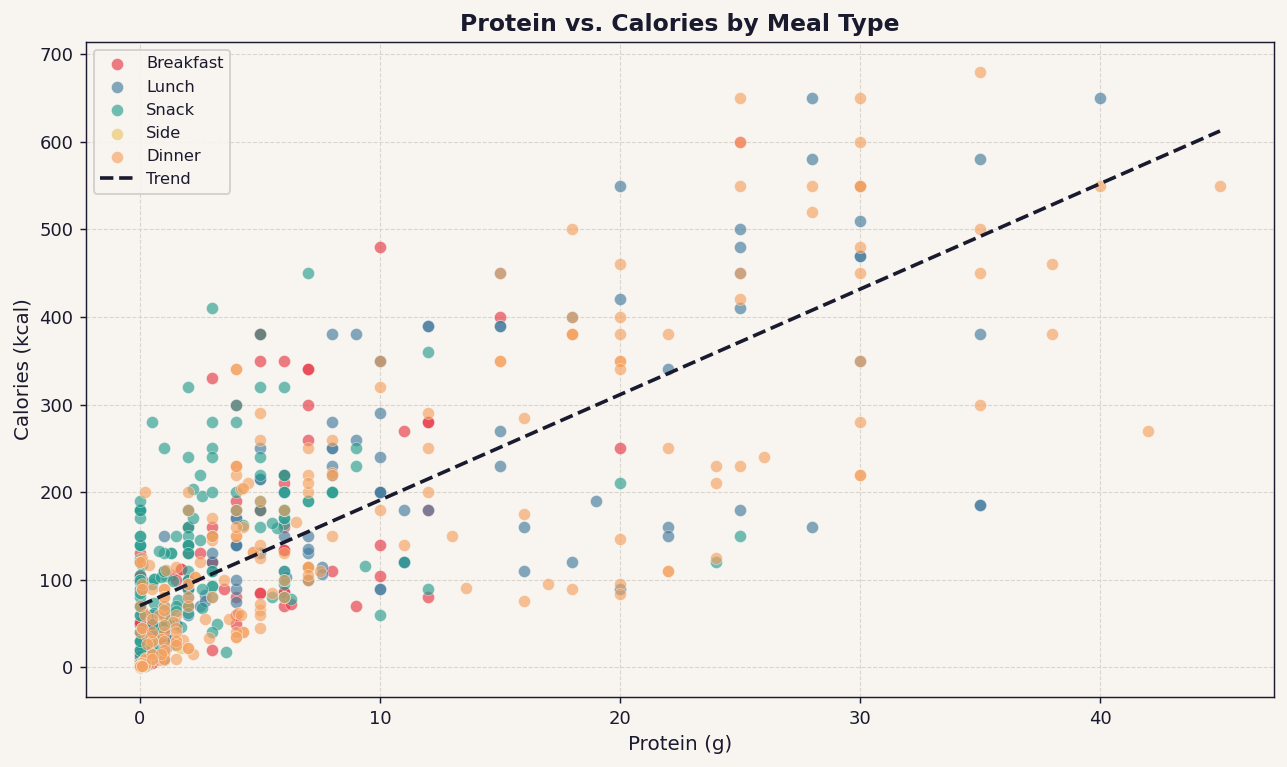

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor(BG)

for i, meal in enumerate(meal_order):
    sub = df[df["meal_type"] == meal]
    ax.scatter(sub["protein_g"], sub["calories_kcal"],
               color=PALETTE[i], alpha=0.65, s=45, label=meal, edgecolors="white", linewidth=0.3)

# Regression line
from numpy.polynomial import polynomial as P
x = df["protein_g"].dropna()
y = df.loc[x.index, "calories_kcal"]
c = np.polyfit(x, y, 1)
xr = np.linspace(x.min(), x.max(), 200)
ax.plot(xr, np.polyval(c, xr), color=DARK, linewidth=2, linestyle="--", label="Trend")

ax.set_xlabel("Protein (g)")
ax.set_ylabel("Calories (kcal)")
ax.set_title("Protein vs. Calories by Meal Type")
ax.legend(framealpha=0.9, fontsize=9)
ax.yaxis.grid(True); ax.xaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("protein_vs_calories.png", bbox_inches="tight", facecolor=BG)
plt.show()


##Top 10 Highest-Calorie Foods


,food_item,calories_kcal,meal_type,category
1,Chicken Alfredo (1.5 cups),680 kcal,Dinner,Meal/Pasta
2,Reuben Sandwich,650 kcal,Lunch,Meal/Processed
3,Beef Burrito (large),650 kcal,Dinner,Meal/Processed
4,Chicken Parm Sandwich,650 kcal,Lunch,Meal/Processed
5,Carbonara (1.5 cups),650 kcal,Dinner,Meal/Pasta
6,Eggs Benedict (1 serving),600 kcal,Breakfast,Meal/Protein
7,Gyro (1 sandwich),600 kcal,Dinner,Meal/Meat
8,Beef Wellington (1 slice),600 kcal,Dinner,Meal/Meat
9,Meatball Sub (6 inch),580 kcal,Lunch,Meal/Processed
10,Club Sandwich,580 kcal,Lunch,Meal/Processed


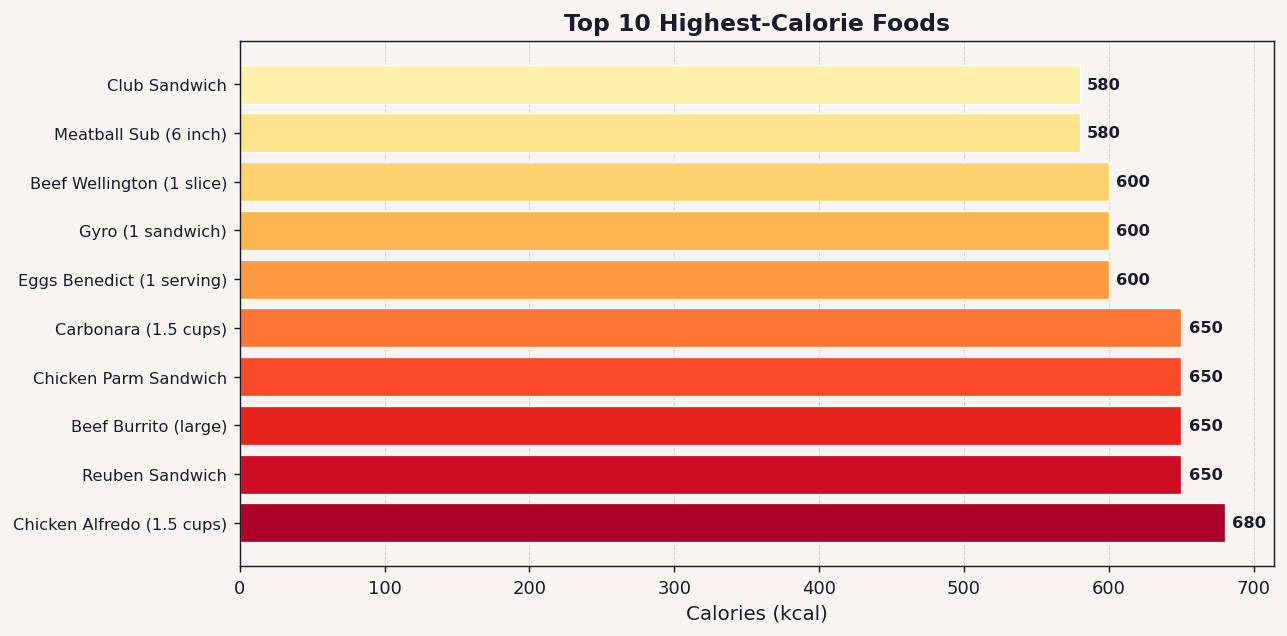

In [12]:
top10 = df.nlargest(10, "calories_kcal")[["food_item", "calories_kcal", "meal_type", "category"]].reset_index(drop=True)
top10.index += 1

display(top10.style
        .background_gradient(subset=["calories_kcal"], cmap="YlOrRd")
        .set_caption("Top 10 most calorie-dense foods in the dataset")
        .format({"calories_kcal": "{:.0f} kcal"}))

# Visual
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(top10))
bars = ax.barh(y_pos, top10["calories_kcal"],
               color=sns.color_palette("YlOrRd_r", len(top10)),
               edgecolor="white", linewidth=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(top10["food_item"], fontsize=9)
ax.set_xlabel("Calories (kcal)")
ax.set_title("Top 10 Highest-Calorie Foods")
ax.xaxis.grid(True); ax.set_axisbelow(True)
for bar, val in zip(bars, top10["calories_kcal"]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}", va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("top10_calories.png", bbox_inches="tight", facecolor=BG)
plt.show()


##Key Findings & Takeaways

| # | Insight |
|---|---------|
| 1 | **Dinner is the most caloric meal** on average, followed closely by Lunch. |
| 2 | **Fat is the strongest predictor of calories** (r ≈ 0.82), more so than carbohydrates. |
| 3 | **Meals & Processed foods** have the highest average calorie densities among categories. |
| 4 | **Fiber is largely independent of other macros**, making it a useful standalone health signal. |
| 5 | The calorie distribution is **right-skewed** — a small number of high-calorie items dominate. |


